In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from random import randrange
import warnings
from scipy import linalg    
import seaborn as sns
from scipy.stats import linregress
from scipy.spatial import Delaunay
from collections import defaultdict
import numpy as np
import pandas as pd
from scipy.spatial.distance import cdist
from tqdm import tqdm
warnings.filterwarnings('ignore')
import ast
import re

datadir = '/Users/billiemeadowcroft/Dropbox/PostDocCode/FrishmanMethod/InferenceScripts/PythonContained/dataout/'
datadirClus = '/Users/billiemeadowcroft/Dropbox/PostDocCode/FrishmanMethod/InferenceScripts/PythonContained/outCluster/'
datadirTraj = '/Users/billiemeadowcroft/Dropbox/PostDocCode/AmandaData/DataFrames/'
plotsdir='/Users/billiemeadowcroft/Dropbox/PostDocCode/FrishmanMethod/Plots/'
cmap = plt.cm.get_cmap('BuPu')
clrs=["#c7e9b4","#7fcdbb","#41b6c4","#1d91c0","#225ea8","#0c2c84","#c7e9b4","#7fcdbb","#41b6c4","#1d91c0","#225ea8","#0c2c84"]
clrs2=["#fc8d59","#d7301f","#650be3","#272FCD","#318395","#4575b4","#91bfdb","#313695","#4575b4","#313695","#fef0d9","#fdcc8a","#fc8d59","#d7301f","#4575b4","#313695","#313695","#4575b4","#91bfdb","#313695","#4575b4","#313695"]

In [3]:
def compute_gr(df, box_size,r_max,nummbins):
    coords = df[['x', 'y']].values
    timesteps = df['timestep'].values
    #N = len(coords)
    NCells = len(np.unique(df['id'].values))
    bins = np.linspace(0, r_max, nummbins)  # Define bins for histogram
    gr = np.zeros(len(bins) - 1)
    AvNs = []
    #Ncounts = 0
    print("Number of particles:",NCells)
    for tt in np.unique(timesteps):
        print(f"Processing timestep {tt} of {np.max(timesteps)}")
        coords_tt = coords[timesteps == tt]
        N_tt = len(coords_tt)
        if N_tt < 2:
            continue
        AvNs.append(N_tt)
        for i in range(N_tt):
            rij = coords_tt - coords_tt[i]
            # Minimum image convention
            #rij -= box_size * np.round(rij / box_size)
            distances = np.linalg.norm(rij, axis=1)
            distances = distances[(distances > 0) & (distances < r_max)]
            hist, _ = np.histogram(distances, bins=bins)
            gr += hist
    # Normalization
    N=np.mean(AvNs) # Average number of particles per frame
    TstepsTot = len(np.unique(timesteps))
    gr = gr/ TstepsTot #average gr per frame
    rho = N / (box_size ** 2) # Average density
    shell_areas = np.pi * (bins[1:] ** 2 - bins[:-1] ** 2)
    gr = gr / ( N * rho * shell_areas)

    r_centers = 0.5 * (bins[1:] + bins[:-1])
    return r_centers, gr, N

In [4]:
def compute_wdot(g_r, gradv_r, g3_rr, r_vals, rho0, gamma, T):
    N = len(r_vals)
    dr = np.gradient(r_vals)  # Allow for uneven bins

    # First term: ∫ g(r)([∇v(r)]^2 - T ∇²v(r)) dr
    laplacian_v = np.gradient(gradv_r, r_vals)
     

    first_integrand = g_r * (gradv_r**2 - T * laplacian_v)
    term1 = np.sum(first_integrand * dr)

    # Second term: ∬ g3(r, r') ∇v(r)·∇v(r') dr dr'
    outer_grad = np.outer(gradv_r, gradv_r)
    term2_integrand = g3_rr * outer_grad

    # Use outer product of dr for 2D area weights
    dr_matrix = np.outer(dr, dr)
    term2 = np.sum(term2_integrand * dr_matrix)

    # Final expression
    wdot = (rho0 / gamma) * term1 + (rho0**2 / gamma) * term2
    return wdot


In [5]:
clrs = [
    'grey',
    '#a1dab4',
    '#41b6c4',
    '#2c7fb8',
    '#253494',
    '#225ea8',
    '#2F4F4F',
    '#4682B4',
    "#665197", 
    '#228B22',
    "#CF7676",  # Saddle Brown
    '#A0522D',  # Sienna
    '#B22222',  # Firebrick
    '#D2B48C',  # Tan
    '#6B8E23',  # Olive Drab
    '#DAA520',  # Goldenrod
    '#2F4F4F'   # Dark Slate Gray
]

In [6]:
# outputs vector of size NumBasisFunctions
def laguerre_polynomialsExp(r,NumBasisFunctions,r_mod):
    # Initialize Laguerre*exp(-r) and their derivatives
    L_exp = [np.exp(-r/r_mod), (1 - r) * np.exp(-r/r_mod)]
    dL_exp = [-np.exp(-r/r_mod), (r - 2) * np.exp(-r/r_mod)]

    # Recursively build L_k(r) * exp(-r)
    L_plain = [1.0, 1 - r]  # plain Laguerre polynomials L_k(r)

    for k in range(2, NumBasisFunctions):
        # Compute next Laguerre polynomial
        Lk = ((2*k - 1 - r) * L_plain[k-1] - (k - 1) * L_plain[k-2]) / k
        L_plain.append(Lk)

        # Multiply by exp(-r)
        Lk_exp = Lk * np.exp(-r/r_mod)
        L_exp.append(Lk_exp)

        # Compute the derivative of L_k(r) * exp(-r)
        Dlk = -Lk_exp*np.exp(-r/r_mod) + np.exp(-r/r_mod) * (1/r)* (k*Lk-k*L_plain[k-1])
        dL_exp.append(Dlk)

    #print(np.shape(np.reshape(L_exp,5)))
    return L_exp #, dL_exp


Get the random g(r) for this box

In [7]:

Times = [1]
f=0
box_size = 1229.67559057441
r_max=box_size
T=10
N = 1000  # ensure it's an integer
numbins=500
timesteps = np.arange(T)  # Create an array of timesteps from 0 to T-1
total_points = T * N
RandArrayX = np.random.uniform(0, box_size, size=total_points)
RandArrayY = np.random.uniform(0, box_size, size=total_points)
RandArrayT = np.repeat(timesteps, N)
RandArrayID = np.arange(total_points) // N
print("length of random array:", len(RandArrayX), len(RandArrayY), len(RandArrayT), len(RandArrayID))
Rand_df = pd.DataFrame({
    'x': RandArrayX,
    'y': RandArrayY,
    'timestep': RandArrayT,
    'id': RandArrayID
})
r_centers_rand, gr_rand, Ncalc_rand = compute_gr(Rand_df, box_size,r_max,numbins)
print("Av cells per frame in the random:", Ncalc_rand)


    

length of random array: 10000 10000 10000 10000
Number of particles: 10
Processing timestep 0 of 9
Processing timestep 1 of 9
Processing timestep 2 of 9
Processing timestep 3 of 9
Processing timestep 4 of 9
Processing timestep 5 of 9
Processing timestep 6 of 9
Processing timestep 7 of 9
Processing timestep 8 of 9
Processing timestep 9 of 9
Av cells per frame in the random: 1000.0


Read in/get pairwise force

number of cells in gr: 277.5094315773131
number of cells in g3r: 912.2125768931807
shape of g3r, r_vals, gr, Finfer: (299, 299) (299,) (299,) (299,)
number of cells in gr: 186.21977771483364
number of cells in g3r: 51.81930475610728
shape of g3r, r_vals, gr, Finfer: (299, 299) (299,) (299,) (299,)
number of cells in gr: 171.05651181307354
number of cells in g3r: 17.42796037566314
shape of g3r, r_vals, gr, Finfer: (299, 299) (299,) (299,) (299,)
number of cells in gr: 165.65383207658405
number of cells in g3r: 10.33123049951376
shape of g3r, r_vals, gr, Finfer: (299, 299) (299,) (299,) (299,)


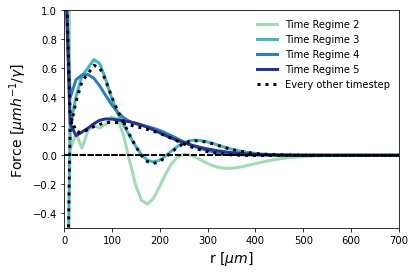

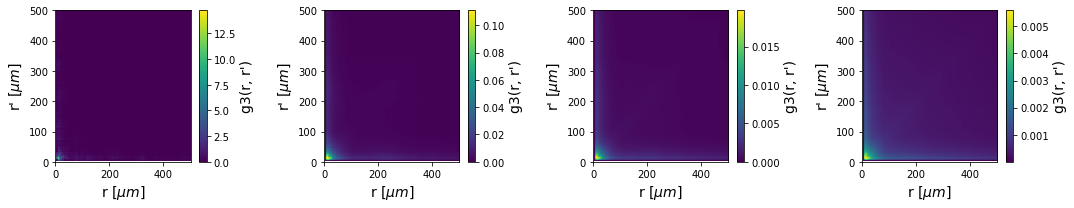

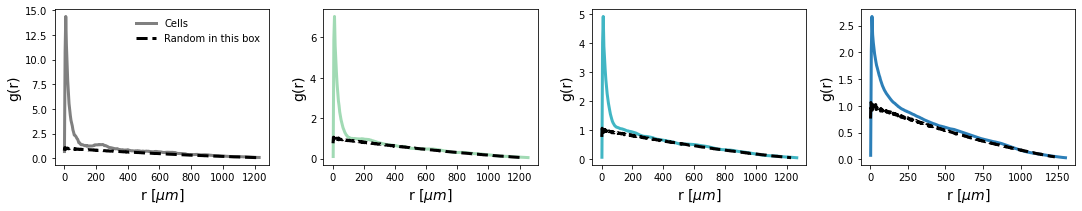

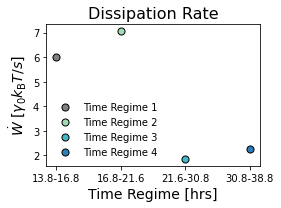

In [9]:
Time_RegimesVV = [13.84, 16.84,21.58,30.81,38.79,46.52]
names  = ['/TimeRegime1','/TimeRegime2','/TimeRegime3','/TimeRegime4','/TimeRegime5','/TimeRegime3/Finf_skip3/','/TimeRegime5/Finf_skip3/']
fig,ax = plt.subplots(1,1,figsize=(6,4))
fig2,ax2 = plt.subplots(1,4,figsize=(15,3))
fig3,ax3 = plt.subplots(1,4,figsize=(15,3))
fig4,ax4 = plt.subplots(1,figsize=(4,3))
AvNumCells = [342,1366.55,2307.2,3239.18]
UnitsFactor = 18.66
for f in range(7):
    name0 = names[f]
    Bm05 = np.load(datadirClus+name0+"/results_Bm05.dat.npy")
    force_coeffs = np.load(datadirClus+name0+"/results_Force_coeffs.dat.npy")
    #Rhist = np.load(datadirClus+name0+"/results_Rhist.dat.npy")
    params = pd.read_csv(datadirClus+name0+"/results_params.dat")
    r_mod,r_nt,r_n1,r_mode = float(params.loc[0, 'r_mod']),float(params.loc[0, 'R_NT']),float(params.loc[0, 'R_N1']),float(params.loc[0, 'R_mode'])
    NumBasisFunctions = int(params.loc[0, 'NumBasisFunctions'])
    NumBins = 100
    box_size = 1229.67559057441
    r_centers = np.linspace(0, box_size, NumBins)

    CCs = np.zeros((NumBasisFunctions,NumBins))
    for k, r in enumerate(r_centers):
        b = laguerre_polynomialsExp(r,NumBasisFunctions,r_mod)
        c = Bm05 @ b
        CCs[:,k] = c
        
    Finfer = force_coeffs.dot(CCs)[0] #it only has 1 dimension

    #if f==0:
    #    ax.plot(r_centers,Finfer[:],color=clrs[f],linestyle = ':',linewidth=3,label = f'Time Regime {f+1}')
    if f>0 and f<=4:
        ax.plot(r_centers,Finfer[:],color=clrs[f],linewidth=3,label = f'Time Regime {f+1}')
    if f==5:
        ax.plot(r_centers,Finfer[:],color='black',linewidth=3,linestyle = ':',label = f'Every other timestep')
    if f>5:
         ax.plot(r_centers,Finfer[:],color='black',linewidth=3,linestyle = ':')
    ax.plot([0,box_size],[0,0],color='black',linewidth=1.5,linestyle='--')
    if f<=3:
        g3r = np.load(datadirClus+names[f] + '/Structure/gr_results_g3r.npy')
        gr = np.load(datadirClus+names[f] + '/Structure/gr_results_gr.npy')
        print("number of cells in gr:", np.sum(gr))
        print("number of cells in g3r:", np.sum(g3r))
        r_vals = np.load(datadirClus+names[f] + '/Structure/gr_results_r_centers.npy')


        # Convert to arrays
        
        ax2[f].set_xlim([0,500])
        ax2[f].set_ylim([0,500])
        ax2[f].imshow(g3r, extent=(r_vals[0], r_vals[-1], r_vals[0], r_vals[-1]), origin='lower', cmap='viridis', aspect='auto',vmin = np.min(g3r),vmax = np.max(g3r))
        ax2[f].set_xlim([0,500])
        ax2[f].set_ylim([0,500])
        if f==0:
            ax3[f].plot(r_vals, gr, color=clrs[f], linewidth=3,label = 'Cells')
            ax3[f].plot(r_centers_rand, gr_rand, color='black', linewidth=3, linestyle='--', label='Random in this box')
        else:
            ax3[f].plot(r_vals, gr, color=clrs[f], linewidth=3)
            ax3[f].plot(r_centers_rand, gr_rand, color='black', linewidth=3, linestyle='--')
        cbar = fig2.colorbar(ax2[f].images[0], ax=ax2[f], orientation='vertical')
        cbar.set_label('g3(r, r\')', fontsize=14)
        Finfer_interp = np.interp(r_vals,r_centers , Finfer)
        print("shape of g3r, r_vals, gr, Finfer:", np.shape(g3r), np.shape(r_vals), np.shape(gr), np.shape(Finfer_interp))
        #print(np.shape(g3r),np.shape(r_vals),np.shape(gr), np.shape(Finfer))
        
        Rho0 = np.divide(AvNumCells[f], box_size**2)  # Average number of cells per unit area
        wdot = compute_wdot(gr, Finfer_interp, g3r, r_vals, Rho0,1, 1)
        ax4.scatter(f, wdot*UnitsFactor, marker = 'o', facecolor=clrs[f], label=f'Time Regime {f+1}', s=50,edgecolor='black')
        ax3[f].set_xlabel('r [$\mu m$]', fontsize=14)
        ax3[f].set_ylabel('g(r)', fontsize=14)
        #ax3[f].set_title(f'Time Regime {f+1}', fontsize=16)
        ax2[f].set_xlabel('r [$\mu m$]', fontsize=14)
        ax2[f].set_ylabel('r\' [$\mu m$]', fontsize=14)
    #ax3[f].set_xlim([0,500])
ax.set_ylim(-0.5,1.)
ax.set_xlim([0,700])
ax3[0].legend(frameon=False, loc = 'upper right')
ax4.legend(frameon=False, loc = 'lower left') 
ax4.set_xlabel('Time Regime [hrs]', fontsize=14)
ax4.set_xticks([0,1,2,3],['13.8-16.8','16.8-21.6','21.6-30.8','30.8-38.8'])
ax4.set_ylabel(r'$\dot{W}$ [$\gamma_{0}k_{\mathrm{B}}T/s$]', fontsize=14)
#+'\nif surrounding fluid has viscosity magnitude $\gamma_{0}$'
ax4.set_title('Dissipation Rate', fontsize=16) 
ax.set_xlabel('r [$\mu m$]', fontsize=14)
ax.set_ylabel(r'Force [$\mu m h^{-1}/\gamma$]', fontsize=14) 
ax.legend(frameon=False, loc = 'upper right')
fig2.tight_layout()
fig3.tight_layout()
fig4.tight_layout()
fig.savefig(plotsdir+'Inferred_Force_vs_r.pdf')
fig4.savefig(plotsdir+'DissipationRate_vs_TimeRegime.pdf')



Plot the g3r

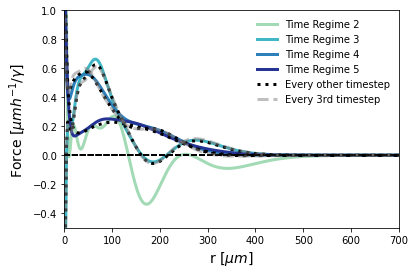

In [38]:
Time_RegimesVV = [13.84, 16.84,21.58,30.81,38.79,46.52]
names  = ['/TimeRegime1','/TimeRegime2','/TimeRegime3','/TimeRegime4','/TimeRegime5','/TimeRegime3/Finf_skip3/','/TimeRegime4/Finf_skip3/','/TimeRegime5/Finf_skip3/','/TimeRegime3/Finf_skip5/','/TimeRegime4/Finf_skip5/']
fig,ax = plt.subplots(1,1,figsize=(6,4))
AvNumCells = [342,1366.55,2307.2,3239.18]
UnitsFactor = 18.66
for f in range(len(names)):
    name0 = names[f]
    Bm05 = np.load(datadirClus+name0+"/results_Bm05.dat.npy")
    force_coeffs = np.load(datadirClus+name0+"/results_Force_coeffs.dat.npy")
    #Rhist = np.load(datadirClus+name0+"/results_Rhist.dat.npy")
    params = pd.read_csv(datadirClus+name0+"/results_params.dat")
    r_mod,r_nt,r_n1,r_mode = float(params.loc[0, 'r_mod']),float(params.loc[0, 'R_NT']),float(params.loc[0, 'R_N1']),float(params.loc[0, 'R_mode'])
    NumBasisFunctions = int(params.loc[0, 'NumBasisFunctions'])
    NumBins = 500
    box_size = 1229.67559057441
    r_centers = np.linspace(0, box_size, NumBins)

    CCs = np.zeros((NumBasisFunctions,NumBins))
    for k, r in enumerate(r_centers):
        b = laguerre_polynomialsExp(r,NumBasisFunctions,r_mod)
        c = Bm05 @ b
        CCs[:,k] = c
        
    Finfer = force_coeffs.dot(CCs)[0] #it only has 1 dimension

    #if f==0:
    #    ax.plot(r_centers,Finfer[:],color=clrs[f],linestyle = ':',linewidth=3,label = f'Time Regime {f+1}')
    if f>0 and f<=4:
        ax.plot(r_centers,Finfer[:],color=clrs[f],linewidth=3,label = f'Time Regime {f+1}')
    if f==5:
        ax.plot(r_centers,Finfer[:],color='black',linewidth=3,linestyle = ':',label = f'Every other timestep')
    if f>5 and f<8:
         ax.plot(r_centers,Finfer[:],color='black',linewidth=3,linestyle = ':')
    if f==8:
        ax.plot(r_centers,Finfer[:],color='grey',linewidth=3,linestyle = '--',alpha = 0.5,label = f'Every 3rd timestep')
    if f>8:
        ax.plot(r_centers,Finfer[:],color='grey',linewidth=3,linestyle = '--',alpha = 0.5)

    ax.plot([0,box_size],[0,0],color='black',linewidth=1.5,linestyle='--')
    
ax.set_ylim(-0.5,1.)
ax.set_xlim([0,700])

ax.set_xlabel('r [$\mu m$]', fontsize=14)
ax.set_ylabel(r'Force [$\mu m h^{-1}/\gamma$]', fontsize=14) 
ax.legend(frameon=False, loc = 'upper right')

fig.savefig(plotsdir+'Inferred_Force_vs_r_timestepskip.pdf')



In [ ]:

print(wdot)

680.3612287193035
